Here, we are going to be investigating whether there is a statistically significant relationship between the Country of Sale and Ingredients/Tags in a database of beauty products.

# Importing libraries and modules

In [61]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Loading in our Dataset

The dataset that we're looking at comes from an API endpoint. Let's look at the original output from the base url.

## Looking at original endpoint output data

In [7]:
base_url = "http://makeup-api.herokuapp.com/api/v1/products.json"

# list of all pertinent endpoint parameters
params = {
    "id": id,
    # "brand": [“almay”, “alva”, “anna sui”, “annabelle”, “benefit”, “boosh”,“burt's bees”,“butter london”, “c’est moi”, “cargo cosmetics”, “china glaze”, “clinique”, “coastal classic creation”, “colourpop”, “covergirl”, “dalish”, “deciem”, “dior”, “dr. hauschka”, “e.l.f.”, “essie”, “fenty”, “glossier”, “green people”, “iman”,“l’oreal”,“lotus cosmetics usa”, “maia's mineral galaxy”, “marcelle”, “marienatie”, “maybelline”, “milani”, “mineral fusion”, “misa”, “mistura”, “moov”, “nudus”, “nyx”,“orly”, “pacifica”, “penny lane organics”, “physicians formula”, “piggy paint”, “pure anada”, “rejuva minerals”, “revlon”, “sally b's skin yummies”, “salon perfect”,“sante”, “sinful colours”, “smashbox”, “stila”, “suncoat”, “w3llpeople”, “wet n wild”, “zorah”, “zorah biocosmetiques”], 
    "brand": "brand",
    "name": "name",
    "price": "price",
    "price_sign": "price_sign",
    "currency" : "currency",
    "rating": "rating",
    # "tag_list": ["cruelty free", "Vegan", "Chemical Free", "Organic", "Canadian", "CertClean", "Dairy Free", "EWG Verified", "EcoCert", "Fair Trade", "Gluten Free", "Hypoallergenic", "Natural", "No Talc", "Non-GMO", "Peanut Free Product", "Sugar Free", "USDA Organic", "alcohol free", "oil free", "purpicks", "silicone free", "water free"],
    "tag_list": ["tag_list"],
    "image_link": "image_link",
    "product_type" : "product_type",
    "category" : "category",
    "description": "description",
    "created_at": "created_at",
    "updated_at" : "updated_at"
    }


response = requests.get(base_url, timeout=30)
response.raise_for_status()
data = response.json()

print(data[0])

{'id': 1048, 'brand': 'colourpop', 'name': 'Lippie Pencil', 'price': '5.0', 'price_sign': '$', 'currency': 'CAD', 'image_link': 'https://cdn.shopify.com/s/files/1/1338/0845/collections/lippie-pencil_grande.jpg?v=1512588769', 'product_link': 'https://colourpop.com/collections/lippie-pencil', 'website_link': 'https://colourpop.com', 'description': 'Lippie Pencil A long-wearing and high-intensity lip pencil that glides on easily and prevents feathering. Many of our Lippie Stix have a coordinating Lippie Pencil designed to compliment it perfectly, but feel free to mix and match!', 'rating': None, 'category': 'pencil', 'product_type': 'lip_liner', 'tag_list': ['cruelty free', 'Vegan'], 'created_at': '2018-07-08T23:45:08.056Z', 'updated_at': '2018-07-09T00:53:23.301Z', 'product_api_url': 'http://makeup-api.herokuapp.com/api/v1/products/1048.json', 'api_featured_image': '//s3.amazonaws.com/donovanbailey/products/api_featured_images/000/001/048/original/open-uri20180708-4-13okqci?1531093614', 

In [8]:
data[0].keys()

dict_keys(['id', 'brand', 'name', 'price', 'price_sign', 'currency', 'image_link', 'product_link', 'website_link', 'description', 'rating', 'category', 'product_type', 'tag_list', 'created_at', 'updated_at', 'product_api_url', 'api_featured_image', 'product_colors'])

## Preprocessing the data

In [38]:
clean_data = []
for row in data:
    clean_data.append({
        "id" : row["id"],
        "brand" : row["brand"],
        "name" : row['name'],
        "price": row["price"],
        "price_sign": row["price_sign"],
        "currency" : row["currency"],
        "category" : row["category"],
        "product_type" : row["product_type"],
        "tag_list" : row["tag_list"],
        "rating" : row["rating"]
    })

df = pd.DataFrame(clean_data)
print(df.shape)
df.head()


(931, 10)


,id,brand,name,price,price_sign,currency,category,product_type,tag_list,rating
0,1048,colourpop,Lippie Pencil,5.0,$,CAD,pencil,lip_liner,"[cruelty free, Vegan]",NaN
1,1047,colourpop,Blotted Lip,5.5,$,CAD,lipstick,lipstick,"[cruelty free, Vegan]",NaN
2,1046,colourpop,Lippie Stix,5.5,$,CAD,lipstick,lipstick,"[cruelty free, Vegan]",NaN
3,1045,colourpop,No Filter Foundation,12.0,$,CAD,liquid,foundation,"[cruelty free, Vegan]",NaN
4,1044,boosh,Lipstick,26.0,$,CAD,lipstick,lipstick,"[Chemical Free, Organic]",NaN


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            931 non-null    int64  
 1   brand         919 non-null    object 
 2   name          931 non-null    object 
 3   price         917 non-null    object 
 4   price_sign    368 non-null    object 
 5   currency      368 non-null    object 
 6   category      517 non-null    object 
 7   product_type  931 non-null    object 
 8   tag_list      931 non-null    object 
 9   rating        340 non-null    float64
dtypes: float64(1), int64(1), object(8)
memory usage: 72.9+ KB


In [54]:
# letting pandas infer appropriate data types for each column
df = df.convert_dtypes()
# correcting the dtype for the price column
df["price"] = df["price"].astype(float)

# Understanding the data

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            931 non-null    Int64  
 1   brand         919 non-null    string 
 2   name          931 non-null    string 
 3   price         917 non-null    float64
 4   price_sign    368 non-null    string 
 5   currency      368 non-null    string 
 6   category      517 non-null    string 
 7   product_type  931 non-null    string 
 8   tag_list      931 non-null    object 
 9   rating        340 non-null    Float64
dtypes: Float64(1), Int64(1), float64(1), object(1), string(6)
memory usage: 74.7+ KB


In [47]:
df.describe(include='all')

,id,brand,name,price,price_sign,currency,category,product_type,tag_list,rating
count,931.0,919,931,917.000000,368,368,517,931,931,340.0
unique,<NA>,57,928,NaN,2,3,15,10,38,<NA>
top,<NA>,nyx,Multi Purpose Powder - Blush & Eye,NaN,$,USD,lipstick,foundation,[],<NA>
freq,<NA>,164,2,NaN,294,287,122,166,732,<NA>
mean,531.163265,NaN,NaN,16.508593,NaN,NaN,NaN,NaN,NaN,4.319118
std,311.054915,NaN,NaN,11.028035,NaN,NaN,NaN,NaN,NaN,0.675849
min,1.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,1.5
25%,263.0,NaN,NaN,8.990000,NaN,NaN,NaN,NaN,NaN,4.0
50%,518.0,NaN,NaN,13.990000,NaN,NaN,NaN,NaN,NaN,4.5
75%,814.5,NaN,NaN,22.000000,NaN,NaN,NaN,NaN,NaN,5.0


## Let's get familiar with Countries of Sale

<StringArray>
['CAD', 'USD', <NA>, 'GBP']
Length: 4, dtype: string


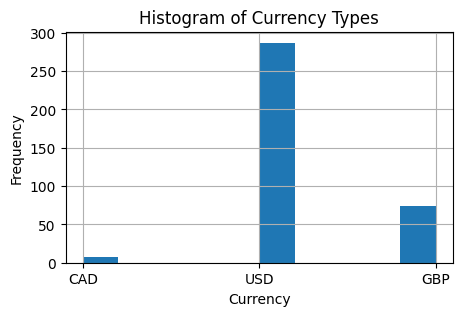

In [52]:
print(df['currency'].unique())

plt.figure(figsize=(5,3))
plt.title('Histogram of Currency Types')
df['currency'].hist()
plt.xlabel('Currency')
plt.ylabel('Frequency')
plt.show()

In [ ]:
print(df['price_sign'].unique())
# USD and CAD share the same currency symbol, so price_sign isn't a reliable column to include in our dataset

<StringArray>
['$', <NA>, '£']
Length: 3, dtype: string


The dataset includes products sold in Canada, Great Britain, and the United States.

In [82]:
df[df['currency'].isnull()]

,id,brand,name,price,price_sign,currency,category,product_type,tag_list,rating
274,772,clinique,Clinique Pop&trade; Oil Lip & Cheek Glow,NaN,<NA>,<NA>,<NA>,blush,[],<NA>
369,657,iman,Cover Cream Clay Medium Deep,NaN,<NA>,<NA>,cream,foundation,[],<NA>
370,656,iman,Corrective Concealer Clay,NaN,<NA>,<NA>,concealer,foundation,[],<NA>
371,655,iman,CC Correct & Cover Clay Medium Deep,NaN,<NA>,<NA>,bb_cc,foundation,[],<NA>
372,654,iman,Luxury Blushing Powder Posh,NaN,<NA>,<NA>,powder,blush,[],<NA>
...,...,...,...,...,...,...,...,...,...,...
926,5,pacifica,Pacifica Stellar Gaze Length & Strength Minera...,28.00,<NA>,<NA>,<NA>,mascara,"[Natural, Vegan]",4.2
927,4,physicians formula,Physicians Formula Organic Wear FakeOut Mascara,15.79,<NA>,<NA>,<NA>,mascara,"[Natural, Gluten Free]",3.9
928,3,physicians formula,Physicians Formula Organic Wear Lash Boosting ...,15.79,<NA>,<NA>,<NA>,mascara,"[Natural, Gluten Free]",3.7
929,2,<NA>,L' Oreal Paris Voluminous Mascara,9.99,<NA>,<NA>,<NA>,mascara,[],4.5


In [79]:
df['currency'].isnull().sum()

np.int64(563)

## Let's get familiar with Product Tags (Ingredients)

Each product has a list of tags, which vary in size/length

In [ ]:
list_lens = [len(tag_list) for tag_list in df['tag_list']]
np.unique(list_lens)

array([0, 1, 2, 3, 4, 5, 7, 8])

Let's identify all of the different tag values

In [ ]:
all_tags = [item for sublist in df['tag_list'] for item in sublist]
np.unique(all_tags)
# solution inspired by this stackoverflow QA thread: https://stackoverflow.com/questions/716477/join-list-of-lists-in-python

array(['Canadian', 'CertClean', 'Chemical Free', 'Dairy Free',
       'EWG Verified', 'EcoCert', 'Fair Trade', 'Gluten Free',
       'Hypoallergenic', 'Natural', 'No Talc', 'Non-GMO', 'Organic',
       'Peanut Free Product', 'Sugar Free', 'USDA Organic', 'Vegan',
       'alcohol free', 'cruelty free', 'oil free', 'purpicks',
       'silicone free', 'water free'], dtype='<U19')

In [ ]:
df['tag_list'].iloc[0]

0                 [cruelty free, Vegan]
1                 [cruelty free, Vegan]
2                 [cruelty free, Vegan]
3                 [cruelty free, Vegan]
4              [Chemical Free, Organic]
                     ...               
926                    [Natural, Vegan]
927              [Natural, Gluten Free]
928              [Natural, Gluten Free]
929                                  []
930    [Natural, Gluten Free, Canadian]
Name: tag_list, Length: 931, dtype: object

# Cleaning the dataset before analysis

In [92]:
df_interim = df[['currency','tag_list']].dropna(subset=['currency'])

In [98]:
df_interim[df_interim['tag_list'].str.len() > 0]

,currency,tag_list
0,CAD,"[cruelty free, Vegan]"
1,CAD,"[cruelty free, Vegan]"
2,CAD,"[cruelty free, Vegan]"
3,CAD,"[cruelty free, Vegan]"
4,CAD,"[Chemical Free, Organic]"
5,CAD,"[water free, cruelty free, alcohol free, oil f..."
6,CAD,"[water free, cruelty free, alcohol free, oil f..."
7,USD,"[purpicks, EcoCert]"
8,USD,"[purpicks, EcoCert]"
9,USD,"[EWG Verified, purpicks, Gluten Free]"


# Misc.

We may find patterns amongst keywords in product names as well

In [78]:
all_names = [name for name in df["name"]]
np.unique(all_names)


array(['\n                            Amethyst\n                            ',
       '\n                            Diabolo\n                            ',
       '\n                            Emerald\n                            ',
       '\n                            Grenat\n                            ',
       '\n                            Jungle Matte\n                            ',
       '\n                            Junon\n                            ',
       '\n                            Matte\n                            ',
       '\n                            Mineral\n                            ',
       '\n                            Miss Satin\n                            ',
       '\n                            Poison Metal\n                            ',
       '\n                            Precious Rocks\n                            ',
       '\n                            Ruby\n                            ',
       '\n                            Sauvage\n    

It looks like there are some pertinent keywords related to ingredients. Let's attempt to extract those from this list of product names.

['cruelty free', 'Vegan', 'cruelty free', 'Vegan']

In [70]:
def unpack_tag_list(tag_list):
    if not tag_list:
        # list is empty
        return None
    else:
        elements = []
        for element in tag_list:
            elements.append(element)
        return elements

unpack_tag_list(df['tag_list'].iloc[0])
# solution inspired by this stackoverflow QA thread: https://stackoverflow.com/questions/57541031/how-do-you-unpack-nested-lists-of-different-lengths

['cruelty free', 'Vegan']